# D-RTRL: diagonal online gradient learning

## Goal

Train a small `braintrace.nn.MiniGRU` on a deterministic sequence while carrying parameter-dimensional eligibility traces forward in time. The notebook uses the same model and task as the pp_prop tutorial so that the learning rule—not the example architecture—is the controlled difference.


## 1. What D-RTRL approximates

Real-Time Recurrent Learning propagates the influence of every parameter on recurrent hidden state. `braintrace.D_RTRL` retains a parameter-dimensional eligibility trace but uses the configured recurrence and VJP approximations rather than storing the full trajectory required by BPTT. In the default diagonal scope, the recurrence drops cross-hidden Jacobian terms:

$$
\epsilon^t \approx D^t \epsilon^{t-1} + J_f^t,
\qquad
\nabla_\theta L = \sum_t \frac{\partial L^t}{\partial h^t}\,\epsilon^t.
$$

This is an online estimator: gradient information is updated during the forward sequence. It should not be described as generally identical to BPTT; equality depends on the configured VJP path and the mathematical regime being tested.


## 2. Setup

The seed fixes parameter initialization. Data are deterministic and require no random-number API outside `brainstate.random`.


In [1]:
import brainstate
import braintools
import braintrace
import jax.numpy as jnp
import matplotlib.pyplot as plt

brainstate.random.seed(7)

## 3. MiniGRU task

Use the repository's `braintrace.nn.MiniGRU`, whose update gate depends on the concatenated input and previous hidden state. This is not a separately implemented minGRU variant. The task maps a short scalar sequence to a fixed affine target.


In [2]:
class SequenceModel(brainstate.nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = braintrace.nn.MiniGRU(in_size=1, out_size=6)
        self.readout = braintrace.nn.Linear(6, 1)

    def update(self, x):
        return self.readout(self.rnn(x))


model = SequenceModel()
inputs = jnp.linspace(-1.0, 1.0, 12).reshape(12, 1, 1)
targets = 0.7 * inputs + 0.2

# The Linear readout is intentionally non-temporal; Section 5 explains
# the compiler diagnostic emitted for it.
learner = braintrace.compile(
    model,
    braintrace.D_RTRL,
    inputs[0],
    batch_size=1,
)
weights = model.states(brainstate.ParamState)
optimizer = braintools.optim.SGD(lr=0.08)
optimizer.register_trainable_weights(weights);

## 4. Drive the sequence with `etrace_grad`

Hidden state and eligibility state are reset together at sequence boundaries. `etrace_grad` owns the loop: it differentiates one local loss per step, carries the accumulated gradient forward, and divides by the step count when `reduction='mean'`. Repeated epoch updates use `brainstate.transform.for_loop`, not a Python training loop.


initial loss: 0.0802
epoch  0 loss: 0.0802
epoch 12 loss: 0.0100
epoch 24 loss: 0.0086
final loss: 0.0086
loss decreased: True


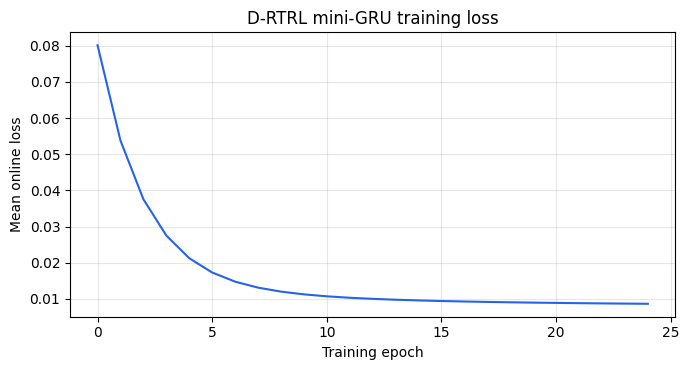

In [3]:
def reset_sequence():
    brainstate.nn.reset_all_states(model, batch_size=1)
    learner.reset_state(batch_size=1)


def evaluate():
    reset_sequence()
    predictions = learner.etrace_evolve(inputs, return_outputs=True)
    return jnp.mean((predictions - targets) ** 2)


def local_loss(x, target):
    prediction = learner(x)
    return jnp.mean((prediction - target) ** 2)


def train_epoch(_):
    reset_sequence()
    # etrace_grad owns the loop, the accumulation and the reduction; local_loss
    # owns the model call. 'mean' divides by the total mask weight -- here T --
    # which is exactly the hand-written `grads / inputs.shape[0]` it replaces.
    grads, step_losses = learner.etrace_grad(
        inputs, targets, step_fn=local_loss,
        reduction='mean', return_value=True,
    )
    optimizer.update(grads)
    return step_losses.mean()


initial_loss = evaluate()
training_losses = brainstate.transform.for_loop(
    train_epoch, jnp.arange(25)
)
final_loss = evaluate()

print(f"initial loss: {float(initial_loss):.4f}")
for epoch in (0, 12, 24):
    print(f"epoch {epoch:2d} loss: {float(training_losses[epoch]):.4f}")
print(f"final loss: {float(final_loss):.4f}")
print("loss decreased:", bool(final_loss < initial_loss))

with plt.style.context("default"), plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
}):
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.plot(training_losses, color="#2563eb")
    ax.set(xlabel="Training epoch", ylabel="Mean online loss")
    ax.set_title("D-RTRL mini-GRU training loss")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()


## 5. Checks and interpretation

The fixed task should finish with a lower loss. This is a descent check, not evidence that D-RTRL equals BPTT. The parameter-dimensional trace scales with the participating parameter and hidden dimensions, so wide recurrent layers can be memory intensive.

A parameter participates in temporal learning only when its path to hidden state is marked by an ETP primitive and respects the no weight-to-weight-to-hidden invariant. A readout that does not feed hidden state is correctly reported as non-temporal.

### Q: Why reset two kinds of state?

**A:** `brainstate.nn.reset_all_states` resets the MiniGRU hidden state. `learner.reset_state` resets eligibility traces and the running index. Resetting only one makes sequence comparisons invalid.

### Q: Why can gradients differ from BPTT?

**A:** The diagonal recurrence and VJP window are estimator choices. Compare against a finite-window oracle only in the regime whose mathematics guarantees equality.

### Q: Where are the larger examples?

**A:** The numbered scripts listed in `examples/drtrl/README.md` cover batching, VJP modes, convolutions, LoRA, and larger tasks. They use the model best suited to each operator demonstration and are not all MiniGRU examples.


## Next steps

- Continue to [pp_prop](pp_prop.ipynb) to run the same MiniGRU task with an input/output-factorized trace.
- See the [algorithm API](../apis/algorithms.rst) for configuration axes and public classes.
- See [Custom ETP Primitives](../advanced/etp_primitives.ipynb) for the advanced primitive-selection rules.
